In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/shahedurrahmanrafin/capstone-csv-2nd/Dataset of Diabetes .csv


# ======================================================
# 1. Import Libraries
# ======================================================

In [2]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import BorderlineSMOTE
from collections import Counter

# ======================================================
# 2. Load Clean Dataset
# ======================================================


In [3]:
file_path = "/kaggle/input/datasets/shahedurrahmanrafin/capstone-csv-2nd/Dataset of Diabetes .csv"
df = pd.read_csv(file_path)

print("Dataset loaded:", df.shape)

Dataset loaded: (1000, 14)


# =========================================
# 4. ENCODING
# =========================================

In [4]:
df_encoded = pd.get_dummies(df, drop_first=True)

# Show result
print(df_encoded.head())
print(df_encoded.columns)

    ID  No_Pation  AGE  Urea  Cr  HbA1c  Chol   TG  HDL  LDL  VLDL   BMI  \
0  502      17975   50   4.7  46    4.9   4.2  0.9  2.4  1.4   0.5  24.0   
1  735      34221   26   4.5  62    4.9   3.7  1.4  1.1  2.1   0.6  23.0   
2  420      47975   50   4.7  46    4.9   4.2  0.9  2.4  1.4   0.5  24.0   
3  680      87656   50   4.7  46    4.9   4.2  0.9  2.4  1.4   0.5  24.0   
4  504      34223   33   7.1  46    4.9   4.9  1.0  0.8  2.0   0.4  21.0   

   Gender_M  Gender_f  CLASS_N   CLASS_P  CLASS_Y  CLASS_Y   
0     False     False     False    False    False     False  
1      True     False     False    False    False     False  
2     False     False     False    False    False     False  
3     False     False     False    False    False     False  
4      True     False     False    False    False     False  
Index(['ID', 'No_Pation', 'AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL',
       'LDL', 'VLDL', 'BMI', 'Gender_M', 'Gender_f', 'CLASS_N ', 'CLASS_P',
       'CLASS_Y', 

# =========================================
# 5. FEATURE SELECTION (FINAL)
# =========================================

In [5]:
df_encoded.columns = df_encoded.columns.str.strip()
df_encoded = df_encoded.loc[:, ~df_encoded.columns.duplicated()]

In [6]:
X = df_encoded.drop(
    ["CLASS_Y", "CLASS_N", "CLASS_P", "ID", "No_Pation"],
    axis=1
)
y = df_encoded["CLASS_Y"]

# ======================================================
# 4. Train-Test Split
# ======================================================


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ======================================================
# 5. Feature Scaling
# ======================================================


Before SMOTETomek: Counter({True: 672, False: 128})
After SMOTETomek: Counter({True: 669, False: 669})


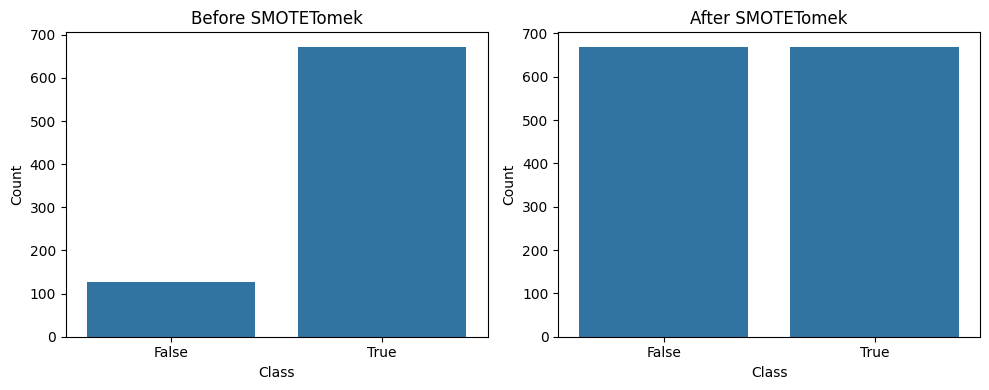

In [8]:
from imblearn.combine import SMOTETomek
from sklearn.preprocessing import StandardScaler
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# BEFORE SMOTETomek
# =========================
print("Before SMOTETomek:", Counter(y_train))

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.countplot(x=y_train)
plt.title("Before SMOTETomek")
plt.xlabel("Class")
plt.ylabel("Count")

# =========================
# APPLY SMOTETomek
# =========================
smote_tomek = SMOTETomek(random_state=42)
X_res, y_res = smote_tomek.fit_resample(X_train, y_train)

print("After SMOTETomek:", Counter(y_res))

# =========================
# AFTER SMOTETomek
# =========================
plt.subplot(1,2,2)
sns.countplot(x=y_res)
plt.title("After SMOTETomek")
plt.xlabel("Class")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

# =========================
# SCALING (AFTER SAMPLING)
# =========================
scaler = StandardScaler()

X_res = scaler.fit_transform(X_res)
X_test = scaler.transform(X_test)

Class Distribution Graph (Before vs After SMOTEENN)

# ======================================================
# 8. Models
# ======================================================


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        random_state=42
    ),

    "CatBoost": CatBoostClassifier(
        iterations=500,
        depth=6,
        learning_rate=0.05,
        random_state=42,
        verbose=0
    ),

    "XGBoost": XGBClassifier(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    ),

    "MLP": MLPClassifier(
        hidden_layer_sizes=(64, 32),
        max_iter=500,
        random_state=42
    )

}

# ==========================================
# 8. Threshold
# ==========================================

# ======================================================
# 9. Evaluation
# ======================================================


Model: Logistic Regression
Best Threshold: 0.1897


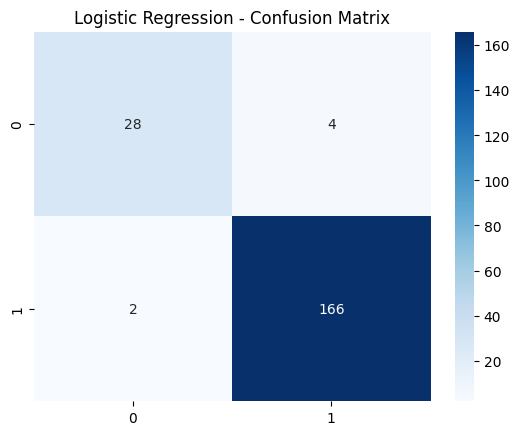

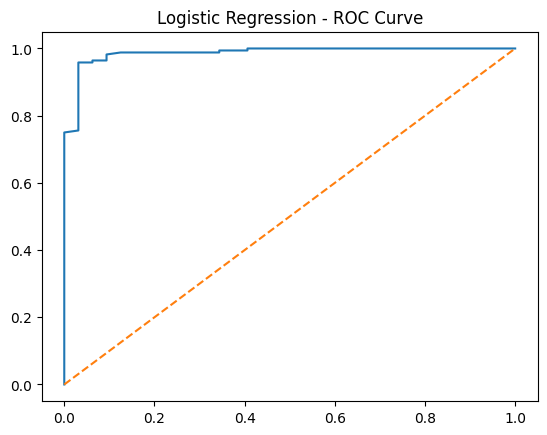

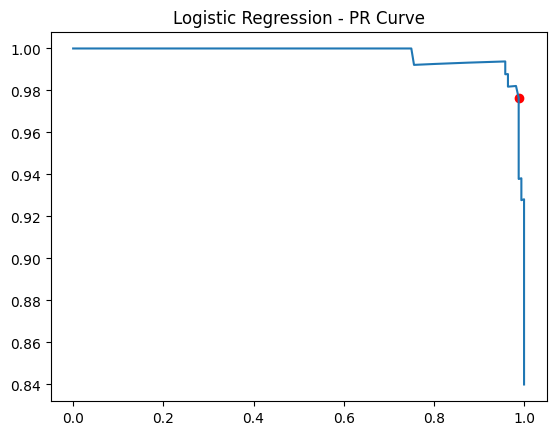


Model: Random Forest
Best Threshold: 0.4562


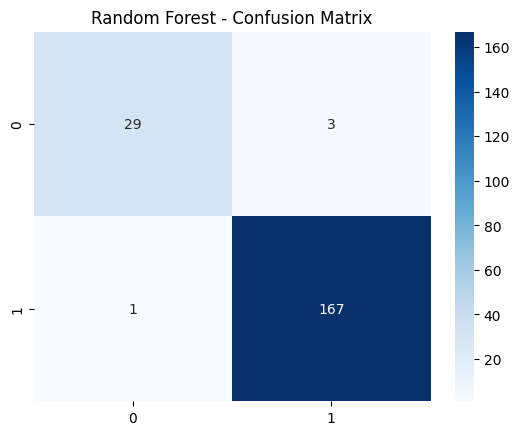

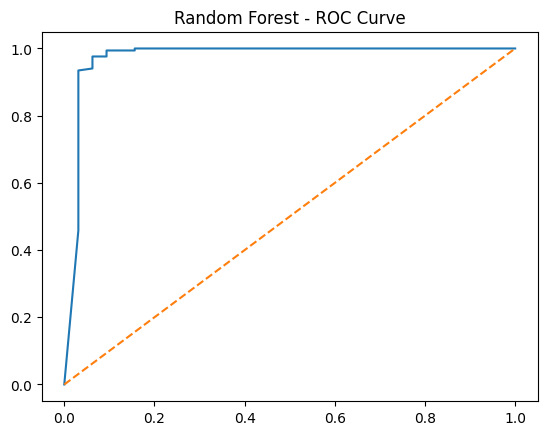

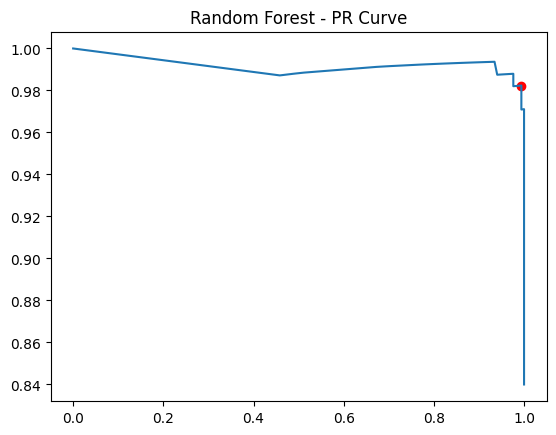


Model: CatBoost
Best Threshold: 0.4457


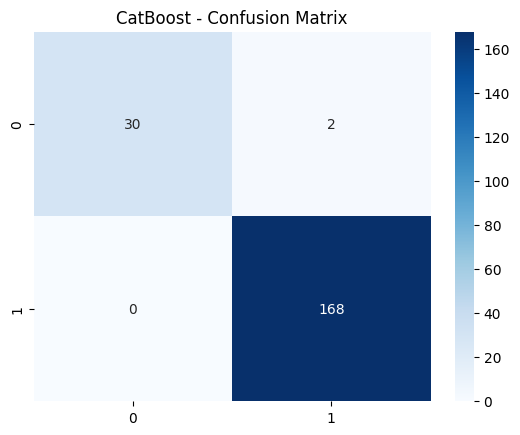

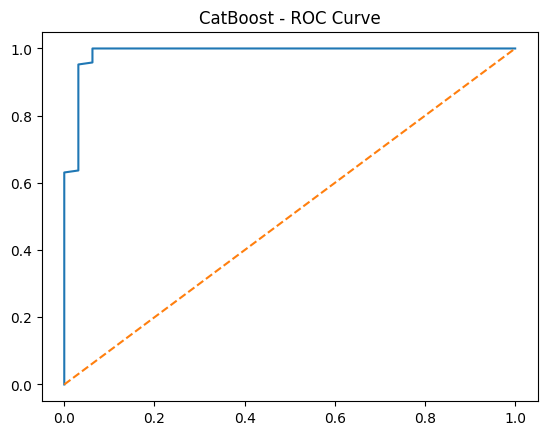

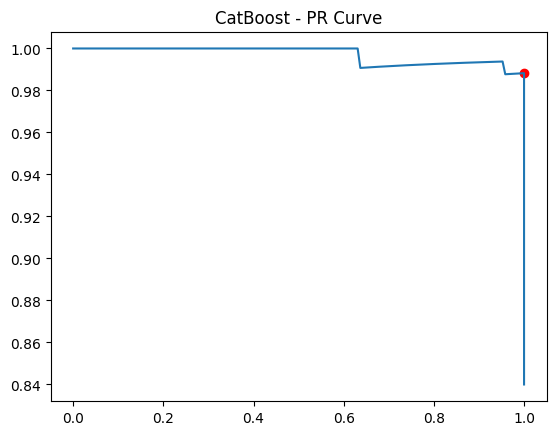


Model: XGBoost
Best Threshold: 0.3989


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:32:06] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


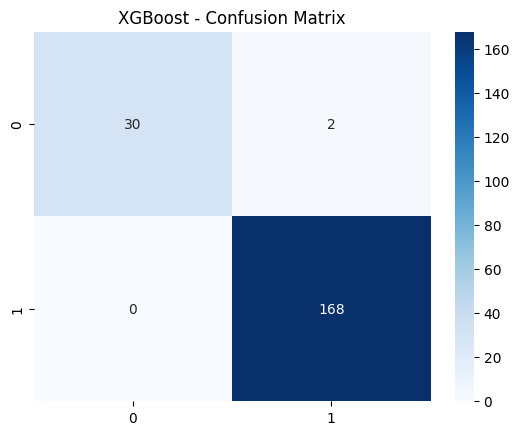

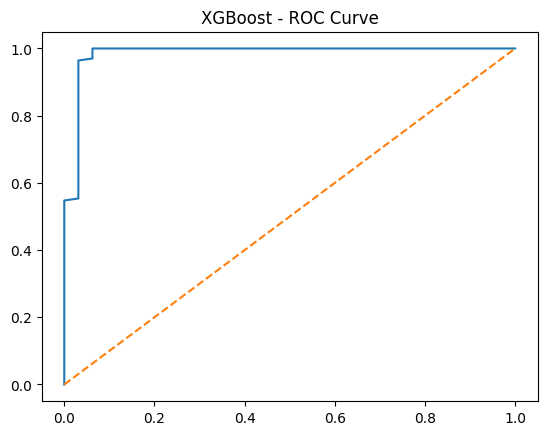

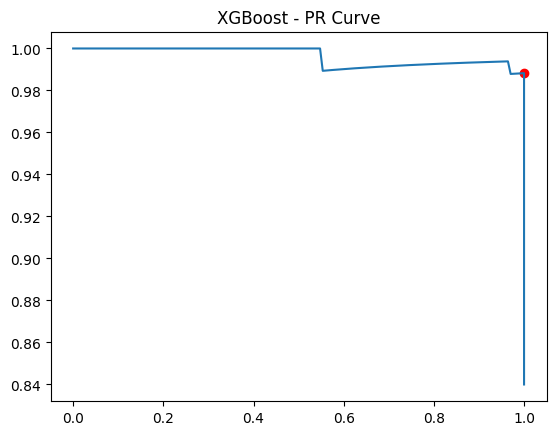


Model: MLP
Best Threshold: 0.5354


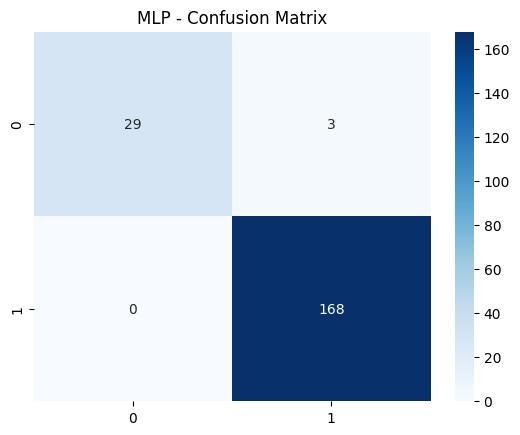

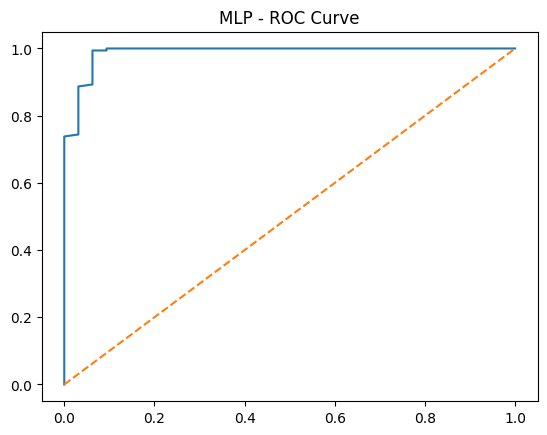

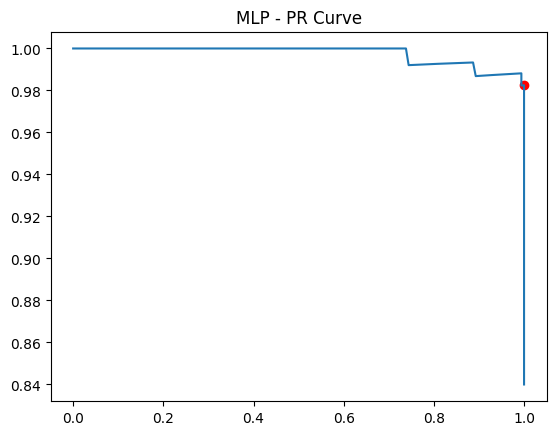


🔥 FINAL COMPARISON
                 Model  Accuracy  Precision    Recall        F1  Balanced Acc  \
2             CatBoost     0.990   0.988235  1.000000  0.994083      0.968750   
4                  MLP     0.985   0.982456  1.000000  0.991150      0.953125   
3              XGBoost     0.990   0.988235  1.000000  0.994083      0.968750   
1        Random Forest     0.980   0.982353  0.994048  0.988166      0.950149   
0  Logistic Regression     0.970   0.976471  0.988095  0.982249      0.931548   

   Specificity       FNR       AUC  Training Time  
2      0.93750  0.000000  0.987165       1.407747  
4      0.90625  0.000000  0.988281       1.660234  
3      0.93750  0.000000  0.984933       0.168739  
1      0.90625  0.005952  0.972842       0.892455  
0      0.87500  0.011905  0.986421       0.006891  

 CLASSIFICATION REPORT
              precision    recall  f1-score  support                Model
False          0.933333  0.875000  0.903226   32.000  Logistic Regression
True     

In [10]:
import time
import numpy as np

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, confusion_matrix,
    roc_auc_score, roc_curve, classification_report,
    precision_recall_curve
)

results = []
all_reports = []

for model_name, model in models.items():

    print("\n========================")
    print("Model:", model_name)

    # Train
    start = time.time()
    model.fit(X_res, y_res)
    train_time = time.time() - start

    # ==============================
    # PROBABILITY
    # ==============================
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)

    # ==============================
    # AUTO THRESHOLD (F1 BASED)
    # ==============================
    precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_prob)

    f1_scores = (2 * precision_vals * recall_vals) / (precision_vals + recall_vals + 1e-8)
    f1_scores = f1_scores[:-1]

    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]

    print("Best Threshold:", round(best_threshold, 4))

    # Prediction
    y_pred = (y_prob >= best_threshold).astype(int)

    # ==============================
    # METRICS
    # ==============================
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    bal_acc = balanced_accuracy_score(y_test, y_pred)

    cm = confusion_matrix(y_test, y_pred)
    TN, FP, FN, TP = cm.ravel()

    specificity = TN / (TN + FP)
    fnr = FN / (FN + TP)

    auc = roc_auc_score(y_test, y_prob)

    # Save results
    results.append([
        model_name,
        acc, precision, recall, f1,
        bal_acc, specificity, fnr, auc,
        train_time
    ])

    # ==============================
    # CLASSIFICATION REPORT
    # ==============================
    report_dict = classification_report(y_test, y_pred, output_dict=True)
    report_df = pd.DataFrame(report_dict).transpose()
    report_df["Model"] = model_name
    all_reports.append(report_df)

    # ==============================
    # VISUALIZATION
    # ==============================

    # Confusion Matrix
    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

    # ROC Curve
    fpr_curve, tpr_curve, _ = roc_curve(y_test, y_prob)
    plt.figure()
    plt.plot(fpr_curve, tpr_curve)
    plt.plot([0,1],[0,1],'--')
    plt.title(f"{model_name} - ROC Curve")
    plt.show()

    # PR Curve
    plt.figure()
    plt.plot(recall_vals, precision_vals)
    plt.scatter(recall_vals[best_idx], precision_vals[best_idx], color='red')
    plt.title(f"{model_name} - PR Curve")
    plt.show()


# =========================================
# AFTER LOOP
# =========================================

columns = [
    "Model","Accuracy","Precision","Recall","F1",
    "Balanced Acc","Specificity","FNR","AUC","Training Time"
]

results_df = pd.DataFrame(results, columns=columns)
results_df = results_df.sort_values(by="Recall", ascending=False)

print("\n🔥 FINAL COMPARISON")
print(results_df)

# Classification Report
final_report_df = pd.concat(all_reports)

print("\n CLASSIFICATION REPORT")
print(final_report_df)

# ======================================================
# 10. Final Results Table
# ======================================================


In [11]:
columns = [
    "Model","Accuracy","Precision","Recall","F1",
    "Balanced Acc","Specificity","FNR","AUC","Training Time"
]

results_df = pd.DataFrame(results, columns=columns)

print("\n🔥 FINAL COMPARISON")
print(results_df.sort_values(by="Recall", ascending=False))


# Classification Report
final_report_df = pd.concat(all_reports)

print("\n📊 CLASSIFICATION REPORT")
print(final_report_df)


🔥 FINAL COMPARISON
                 Model  Accuracy  Precision    Recall        F1  Balanced Acc  \
2             CatBoost     0.990   0.988235  1.000000  0.994083      0.968750   
4                  MLP     0.985   0.982456  1.000000  0.991150      0.953125   
3              XGBoost     0.990   0.988235  1.000000  0.994083      0.968750   
1        Random Forest     0.980   0.982353  0.994048  0.988166      0.950149   
0  Logistic Regression     0.970   0.976471  0.988095  0.982249      0.931548   

   Specificity       FNR       AUC  Training Time  
2      0.93750  0.000000  0.987165       1.407747  
4      0.90625  0.000000  0.988281       1.660234  
3      0.93750  0.000000  0.984933       0.168739  
1      0.90625  0.005952  0.972842       0.892455  
0      0.87500  0.011905  0.986421       0.006891  

📊 CLASSIFICATION REPORT
              precision    recall  f1-score  support                Model
False          0.933333  0.875000  0.903226   32.000  Logistic Regression
True    